In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [21]:
# --- Environment Setup ---
xf = 1000
dt = 0.01
sensor_pos = [250, 500, 1000]
sigma = 50

# Hybrid Rules (The Guards)
r_mode1 = 30.0
r_mode3 = r_mode1*1.75

v_modes = {1: 1.0, 2: 5.0, 3: 10.0}
n_modes = {1: 1.0, 2: 25.0, 3: 100.0}

def run_simulation(strategy_type="hybrid"):
    x = 0
    t = 0
    total_risk = 0
    
    logs = {"x": [], "v": [], "risk": [], "mode": [], "t": []}
    
    while x < xf:
        # 1. Sense min distance to threats
        min_dist = min([abs(x - s) for s in sensor_pos])
        
        # 2. Determine Mode
        if strategy_type == "hybrid":
            if min_dist < r_mode1:
                mode = 1
            elif min_dist > r_mode3:
                mode = 3
            else:
                mode = 2
        else:
            # Baseline: Constant Nominal Speed
            mode = 2
            
        v = v_modes[mode]
        n = n_modes[mode]
        
        # 3. Calculate instantaneous risk
        # Sum of risks from all sensors
        current_risk_val = sum([n * np.exp(-abs(x - s) / sigma) for s in sensor_pos])
        
        # 4. Log and Update
        logs["x"].append(x)
        logs["v"].append(v)
        logs["risk"].append(current_risk_val)
        logs["mode"].append(mode)
        logs["t"].append(t)
        
        total_risk += current_risk_val * dt
        t += dt
        x += v * dt
        
    return logs, t, total_risk

# Run both
hybrid_logs, hybrid_time, hybrid_risk = run_simulation("hybrid")
base_logs, base_time, base_risk = run_simulation("baseline")

# --- Results Table ---
print(f"{'Strategy':<15} | {'Time (s)':<10} | {'Total Cost':<12}")
print("-" * 45)
print(f"{'Baseline':<15} | {base_time:<10.2f} | {base_risk:<12.4f}")
print(f"{'Hybrid':<15} | {hybrid_time:<10.2f} | {hybrid_risk:<12.4f}")

Strategy        | Time (s)   | Total Cost  
---------------------------------------------
Baseline        | 200.01     | 1248.4187   
Hybrid          | 246.21     | 1220.9678   


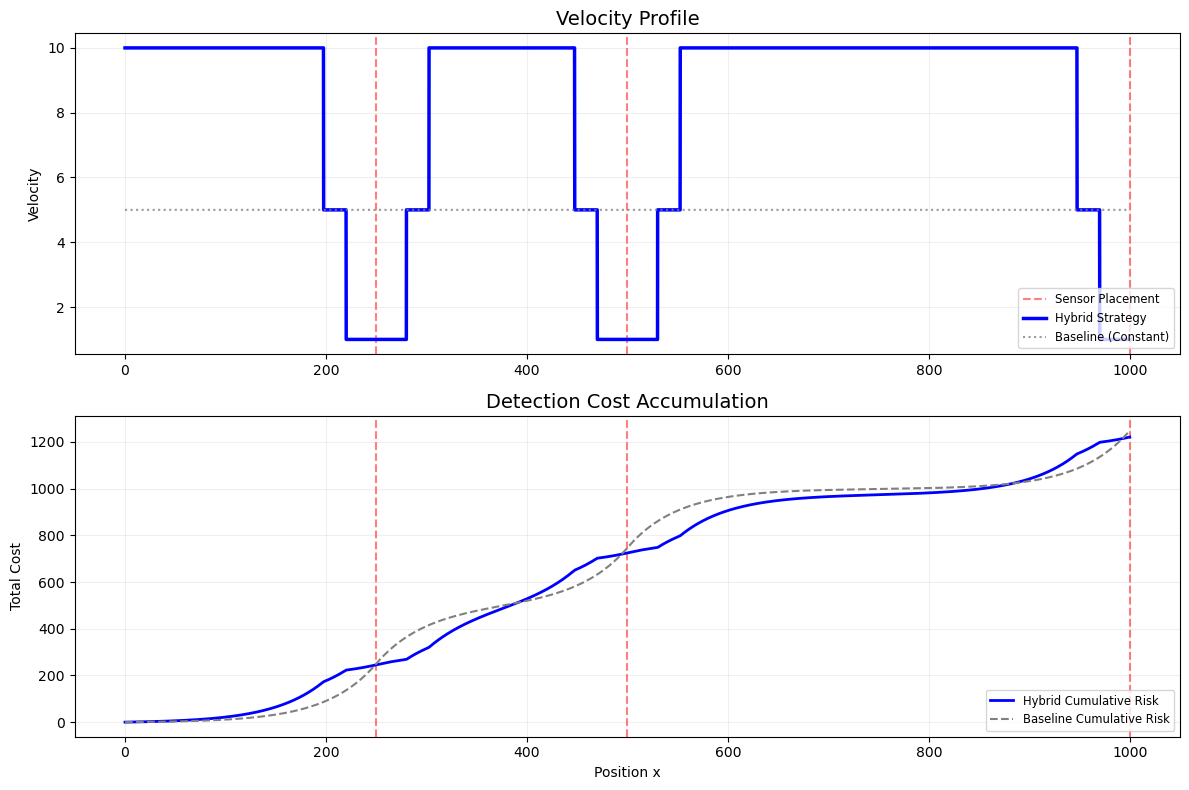

In [22]:
save_this = False

## --- Visualize ---
fig = plt.figure(figsize=(12, 8))

# --- Graph 1: Velocity vs Position ---
ax1 = plt.subplot(2, 1, 1)
# Shaded regions for Sensor 1 and 2 "Slow Zones"
lbl = 'Sensor Placement'
for i, s in enumerate(sensor_pos):
    # Only assign the label to the first sensor iteration
    current_label = lbl if i == 0 else ""
    ax1.axvline(s, color='red', linestyle='--', alpha=0.5, label=current_label)

plt.plot(hybrid_logs["x"], hybrid_logs["v"], label="Hybrid Strategy", color='blue', linewidth=2.5)
plt.plot(base_logs["x"], base_logs["v"], label="Baseline (Constant)", color='gray', linestyle=':', alpha=0.8)

plt.title("Velocity Profile", fontsize=14)
plt.ylabel("Velocity")
plt.legend(loc='lower right', fontsize='small')
plt.grid(True, alpha=0.2)

# --- Graph 2: Risk Heatmap & Accumulation ---
ax2 = plt.subplot(2, 1, 2)

# Create a 'Danger Heatmap' in the background
x_fine = np.linspace(0, 100, 500)
sensitivity = np.zeros_like(x_fine)
for s in sensor_pos:
    current_label = lbl if i == 0 else ""
    ax2.axvline(s, color='red', linestyle='--', alpha=0.5, label=current_label)
# Plot Cumulative Risk
plt.plot(hybrid_logs["x"], np.cumsum(hybrid_logs["risk"]) * dt, label="Hybrid Cumulative Risk", color='blue', linewidth=2)
plt.plot(base_logs["x"], np.cumsum(base_logs["risk"]) * dt, label="Baseline Cumulative Risk", color='gray', linestyle='--')

plt.title("Detection Cost Accumulation", fontsize=14)
plt.xlabel("Position x")
plt.ylabel("Total Cost")
plt.legend(loc='lower right', fontsize='small')
plt.grid(True, alpha=0.2)

plt.tight_layout()
if save_this:
    fig.savefig('hybrid_test_double_sensor.png', dpi=300, bbox_inches='tight')